In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

In [4]:
df= pd.read_csv('/content/travels.csv')

In [5]:
df.head()

,Source,Destination,Distance,Price,Mode,Binary,Payment,Seat,Passenger,Booking,Luggage
0,Goa,Jaipur,1777,892,Train,1,Net Banking,Window,2,Pending,41
1,Chennai,Jaipur,2192,3375,Flight,0,Net Banking,Aisle,3,Confirmed,37
2,Chennai,Kolkata,645,3894,Bus,0,UPI,Middle,5,Pending,7
3,Goa,Delhi,1165,531,Flight,0,Card,Window,4,Cancelled,10
4,Mumbai,Goa,2106,10590,Train,0,Card,Aisle,5,Cancelled,35


In [6]:
df.columns

Index(['Source', 'Destination', 'Distance', 'Price', 'Mode', 'Binary',
       'Payment', 'Seat', 'Passenger', 'Booking', 'Luggage'],
      dtype='object')

In [7]:
df.shape

(250, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Source       250 non-null    object
 1   Destination  250 non-null    object
 2   Distance     250 non-null    int64 
 3   Price        250 non-null    int64 
 4   Mode         250 non-null    object
 5   Binary       250 non-null    int64 
 6   Payment      250 non-null    object
 7   Seat         250 non-null    object
 8   Passenger    250 non-null    int64 
 9   Booking      250 non-null    object
 10  Luggage      250 non-null    int64 
dtypes: int64(5), object(6)
memory usage: 21.6+ KB


In [9]:
## how to convert string to values
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [10]:
df["Source"]=le.fit_transform(df.Source)
df["Destination"]=le.fit_transform(df.Destination)
df["Distance"]=le.fit_transform(df.Distance)
df["Price"]=le.fit_transform(df.Price)
df["Mode"]=le.fit_transform(df.Mode)
df["Binary"]=le.fit_transform(df.Binary)
df["Payment"]=le.fit_transform(df.Payment)
df["Seat"]=le.fit_transform(df.Seat)
df["Passenger"]=le.fit_transform(df.Passenger)
df["Booking"]=le.fit_transform(df.Booking)
df["Luggage"]=le.fit_transform(df.Luggage)

In [11]:
df.describe()

,Source,Destination,Distance,Price,Mode,Binary,Payment,Seat,Passenger,Booking,Luggage
count,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000
mean,4.484000,4.244000,113.648000,122.2720,1.460000,0.504000,1.476000,1.028000,2.02800,1.016000,22.280000
std,2.926431,2.797098,66.853164,71.0288,1.137354,0.500987,1.172571,0.808598,1.38379,0.821244,13.588975
min,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,2.000000,2.000000,55.250000,61.0000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,10.000000
50%,4.000000,4.000000,112.500000,122.5000,2.000000,1.000000,1.500000,1.000000,2.00000,1.000000,23.000000
75%,7.000000,6.000000,170.750000,183.7500,2.000000,1.000000,3.000000,2.000000,3.00000,2.000000,33.750000
max,9.000000,9.000000,231.000000,245.0000,3.000000,1.000000,3.000000,2.000000,4.00000,2.000000,45.000000


In [12]:
df.isna().sum()

,0
Source,0
Destination,0
Distance,0
Price,0
Mode,0
Binary,0
Payment,0
Seat,0
Passenger,0
Booking,0


In [13]:
df.Booking.value_counts()

,count
Booking,
2,86
1,82
0,82


<Axes: xlabel='Booking', ylabel='count'>

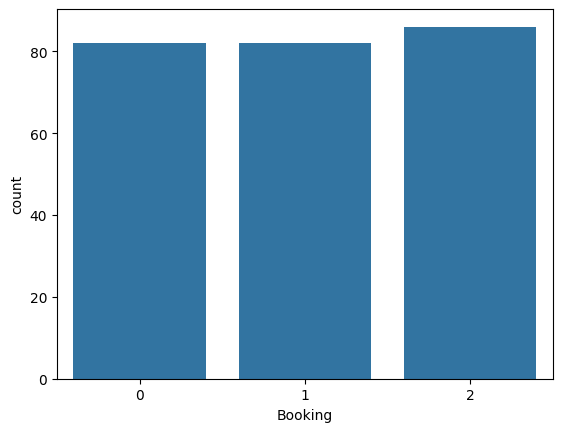

In [14]:
sn.countplot(x='Booking',data=df)

In [15]:
df.Destination.value_counts()

,count
Destination,
3,34
5,30
4,28
0,28
6,27
9,25
1,24
2,22
8,18


<Axes: xlabel='Destination', ylabel='count'>

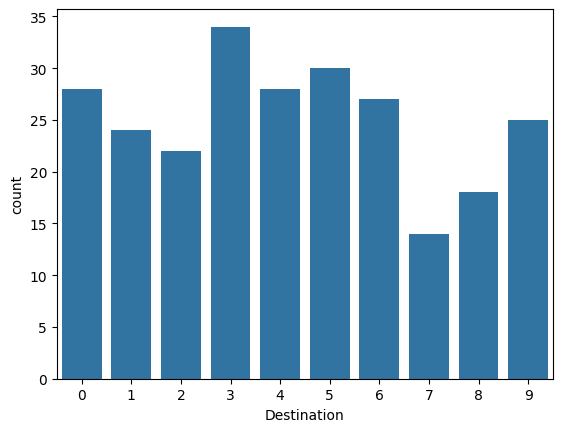

In [16]:
sn.countplot(x='Destination',data=df)

In [17]:
df.Distance.value_counts()

,count
Distance,
187,2
50,2
93,2
25,2
35,2
...,...
188,1
107,1
79,1


<Axes: xlabel='Distance', ylabel='count'>

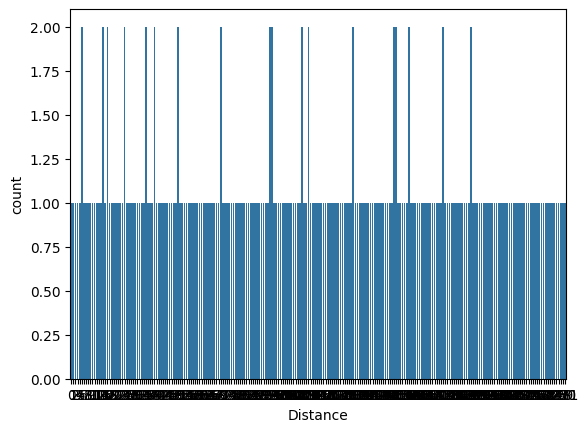

In [18]:
sn.countplot(x='Distance',data=df)

<Axes: xlabel='Booking'>

<Figure size 2000x1800 with 0 Axes>

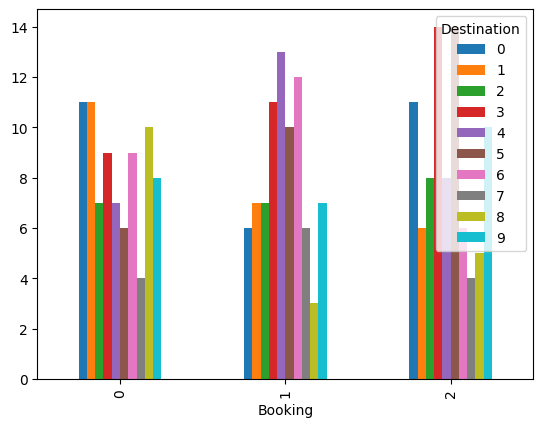

In [19]:
plt.figure(figsize=(20,18))
pd.crosstab(df.Booking,df.Destination).plot(kind="bar")

<Axes: xlabel='Booking'>

<Figure size 4000x3800 with 0 Axes>

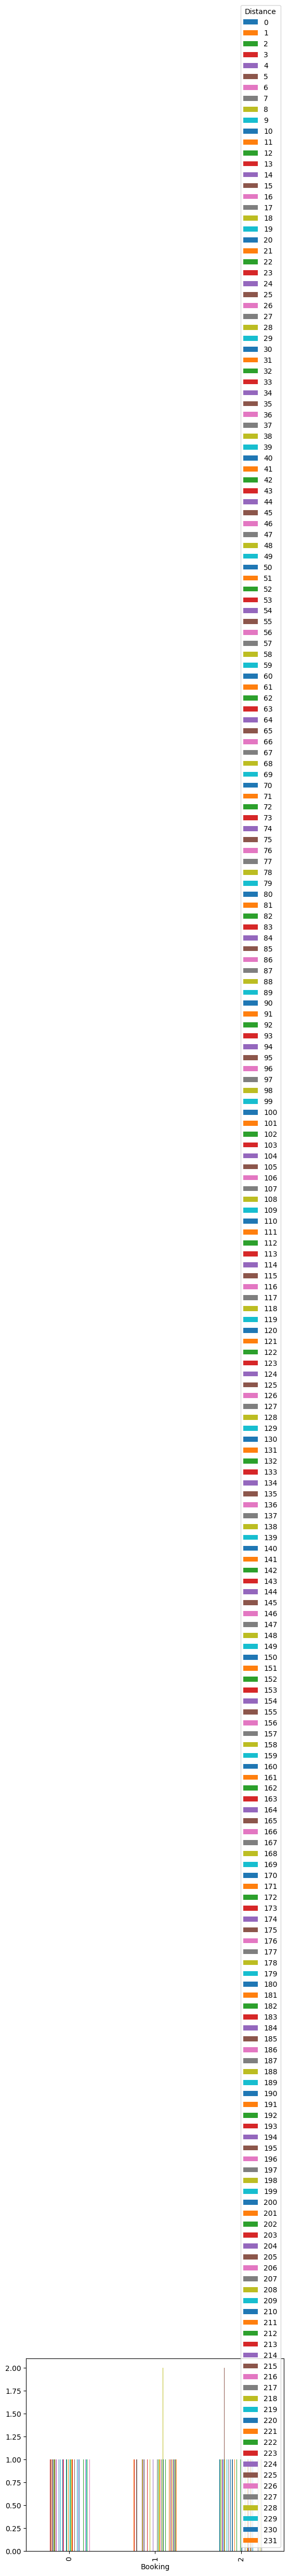

In [20]:
plt.figure(figsize=(40,38))
pd.crosstab(df.Booking,df.Distance).plot(kind="bar")

<Axes: xlabel='Mode'>

<Figure size 2000x1800 with 0 Axes>

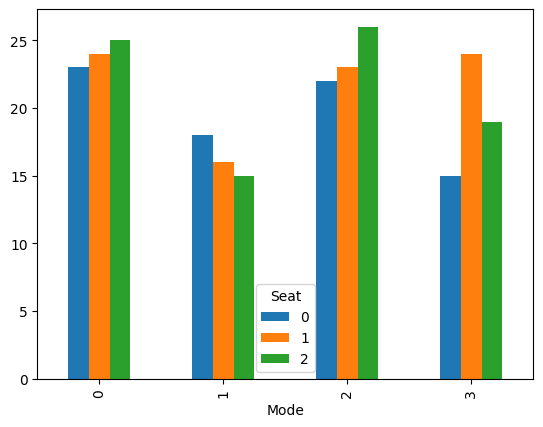

In [21]:
plt.figure(figsize=(20,18))
pd.crosstab(df.Mode,df.Seat).plot(kind="bar")

<Axes: >

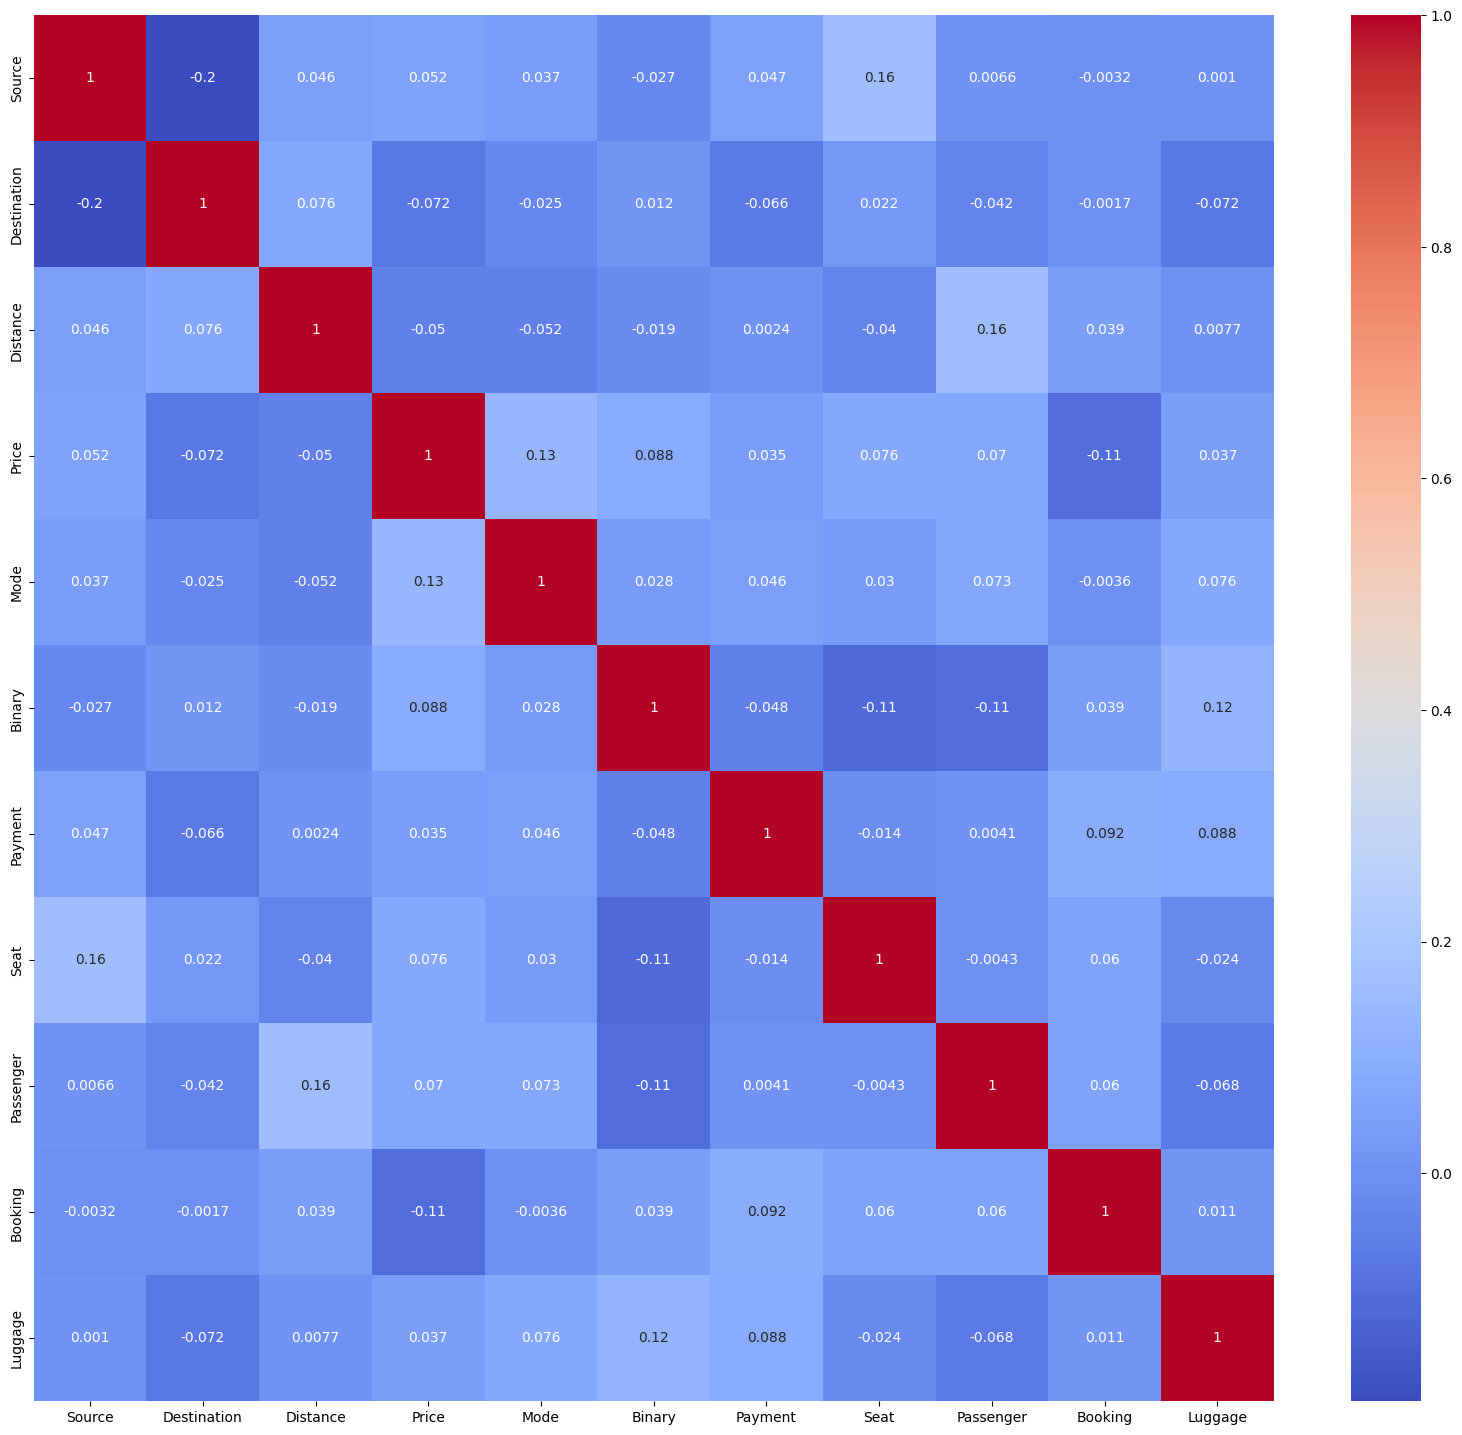

In [22]:
plt.figure(figsize=(20,18))
sn.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [23]:
q1=df.quantile(0.0)
q3=df.quantile(0.90)
iqr=q3-q1

In [24]:
## to save in new dtaframe
df2=df[~((df<(q1-1.5*iqr))| (df>(q3+1.5*iqr)))]

In [25]:
df2.head(2)

,Source,Destination,Distance,Price,Mode,Binary,Payment,Seat,Passenger,Booking,Luggage
0,4,6,161,8,3,1,2,2,1,2,36
1,2,6,201,57,2,0,2,0,2,1,32


In [26]:
df3=df2.dropna()

In [27]:
df3.shape

(250, 11)

In [28]:
def correlation(df3, threshold):
    col_corr = set() # Set of all the names of deleted columns
    corr_matrix = df3.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (abs(corr_matrix.iloc[i, j]) >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colname = corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)

    # Return a new DataFrame with correlated columns dropped
    df_filtered = df3.drop(columns=list(col_corr))
    return df_filtered

In [29]:
corr_matrix=df3.corr()

In [30]:
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)

## For loop to filter columns
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if corr_matrix.iloc[i,j] >= 0.7:
            if columns[j]:
                columns[j] = False

# Selected column store into a variable
selected_columns = df3.columns[columns]
df_with_filtered_columns1 = df3[selected_columns]

In [31]:
df_with_filtered_columns1.columns

Index(['Source', 'Destination', 'Distance', 'Price', 'Mode', 'Binary',
       'Payment', 'Seat', 'Passenger', 'Booking', 'Luggage'],
      dtype='object')

In [32]:
X11=df3[['Source', 'Destination', 'Distance', 'Price', 'Mode',
       'Payment', 'Seat', 'Passenger', 'Booking', 'Luggage']]

In [33]:
y11=df_with_filtered_columns1['Binary']

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X11,y11,test_size=0.2)

In [35]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

In [36]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [37]:
model.score(X_test,y_test)

0.48

In [38]:
model.predict(X_test)

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1])

In [39]:
y_predict=model.predict(X_test)

In [40]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.45      0.61      0.52        23
           1       0.53      0.37      0.43        27

    accuracy                           0.48        50
   macro avg       0.49      0.49      0.48        50
weighted avg       0.49      0.48      0.47        50



In [41]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)
cm

array([[14,  9],
       [17, 10]])

<Axes: >

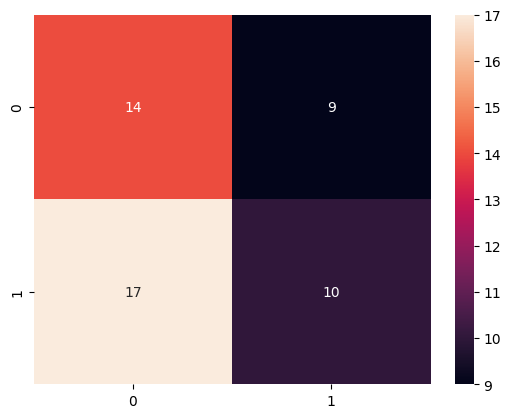

In [42]:
sn.heatmap(cm,annot=True)

In [43]:
y_predict=model.predict_proba(X_test)

In [44]:
proba=y_predict[:,1]

In [45]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold=roc_curve(y_test,proba)

Text(0.5, 1.0, 'ROC_CURVE')

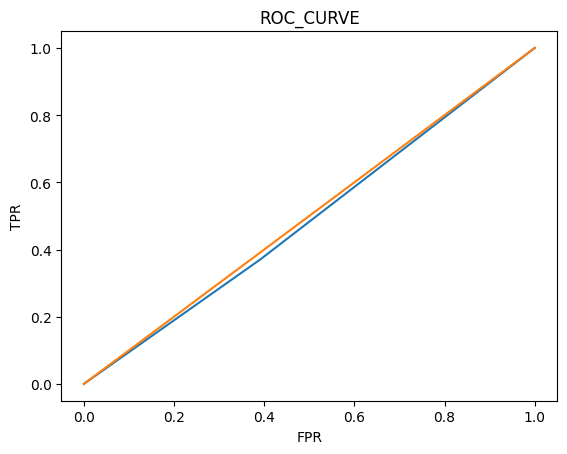

In [46]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC_CURVE")

In [47]:
from sklearn.metrics import roc_auc_score
roc_auc_score=roc_auc_score(y_test,proba)
roc_auc_score

np.float64(0.48953301127214166)

**Hyper Parameters in Decision Tree**

In [48]:
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier()

In [49]:
model1=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            min_samples_leaf=1, min_samples_split=100,
            min_weight_fraction_leaf=0.0, random_state=None)

In [50]:
model1.fit(X_train,y_train)

DecisionTreeClassifier(min_samples_split=100)

In [51]:
model1.score(X_test,y_test)

0.46

In [52]:
model1.predict(X_test)

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1])

In [53]:
y_predict1=model1.predict(X_test)

In [54]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict1)
print(clf)

              precision    recall  f1-score   support

           0       0.45      0.78      0.57        23
           1       0.50      0.19      0.27        27

    accuracy                           0.46        50
   macro avg       0.47      0.48      0.42        50
weighted avg       0.48      0.46      0.41        50



In [55]:
y_predict1=model.predict_proba(X_test)

In [56]:
proba=y_predict1[:,1]

In [57]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold=roc_curve(y_test,proba)

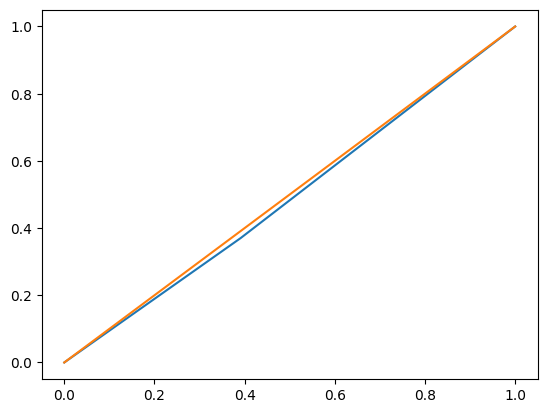

In [58]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])

In [59]:
from sklearn.metrics import roc_auc_score
roc_auc_score=roc_auc_score(y_test,proba)
roc_auc_score

np.float64(0.48953301127214166)

In [60]:
model1.feature_importances_

array([0.        , 0.        , 0.        , 0.51602066, 0.        ,
       0.        , 0.48397934, 0.        , 0.        , 0.        ])

<Axes: >

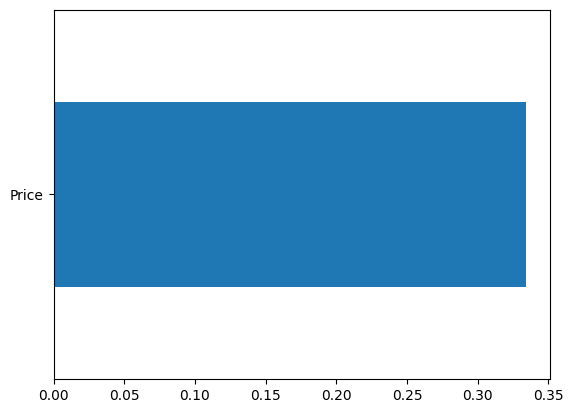

In [61]:
feature=pd.Series(model.feature_importances_,index=X11.columns)
feature.nlargest(1).plot(kind='barh')

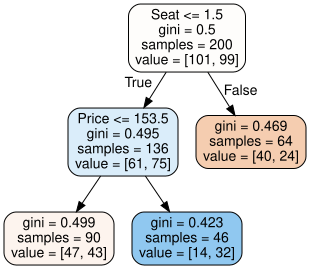

In [62]:
from sklearn import tree
import graphviz
feature_names = X11.columns

dot_data = tree.export_graphviz(model1, out_file=None, filled=True, rounded=True,
                                feature_names=feature_names)

graph = graphviz.Source(dot_data)
graph

In [63]:
param_grid = {'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10],'max_features': ['auto', 'sqrt', 'log2'],
              'max_depth': range(2, 20, 5),'min_samples_leaf': range(100, 400, 50),'min_samples_split': range(200, 500, 50)}

param_grid = {
    'max_depth': [4,8,10],
    'min_samples_leaf': range(100, 400, 200),
    'min_samples_split': range(200, 500, 200),
    'max_features': [5, 10]
}

In [64]:
from sklearn.model_selection import GridSearchCV
CV= GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv= 5)

In [65]:
CV.fit(X_train, y_train)
print(CV.best_params_)

{'max_depth': 4, 'max_features': 5, 'min_samples_leaf': 100, 'min_samples_split': 200}


In [66]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import warnings

In [67]:
KF=KFold(n_splits=5) ## N split to split the testing data

In [69]:
from sklearn.model_selection import cross_val_predict
CVP=cross_val_predict(model1,X11,y11,cv=5)

In [70]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(model1,X11,y11,cv=5)
cvs

array([0.46, 0.54, 0.54, 0.5 , 0.48])

In [71]:
cvs.max()

np.float64(0.54)

In [72]:
cvs.mean()

np.float64(0.504)

In [73]:
from sklearn.model_selection import RepeatedKFold
rp=RepeatedKFold()

In [74]:
from sklearn.model_selection import cross_val_predict
cvp1=cross_val_predict(model1,X11,y11,cv=5)
cvp1

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1])

In [75]:
from sklearn.model_selection import cross_val_score
cvs1=cross_val_score(model1,X11,y11,cv=5)
cvs1

array([0.46, 0.6 , 0.54, 0.5 , 0.48])

In [76]:
cvs1.max(),cvs1.mean()

(np.float64(0.6), np.float64(0.516))